In [1]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
from pandas import read_csv
from scipy.integrate import cumtrapz
from ase.units import kB

# you need to run a ti_spring simulation at t_min
with open("ti_spring.yaml", "r") as f:
        y =  yaml.safe_load(f)

        T0 = y["T"]
        G0 = y["G"]

        rs = read_csv("ti_rs.csv")
        n = int(len(rs)/2)
        forward = rs[:n]
        backward = rs[n:][::-1]
        backward.reset_index(inplace=True)
        dl = forward["dlambda"]
        l = forward["lambda"]
        H1 = forward["enthalpy"]
        H2 = backward["enthalpy"]
        T = T0/l

        w = (cumtrapz(H1,l,initial=0) + cumtrapz(H2,l,initial=0))*0.5

        G = (G0 + 1.5*kB*T0*np.log(l) + w)/l
        plt.plot(T, G, label="RS")
        plt.legend()
        plt.xlabel("T (K)")
        plt.ylabel("G (eV/atom)")


ValueError: If given, length of x along axis must be the same as y.

In [2]:
G

NameError: name 'G' is not defined

Reference State: T0 = 300.0 K, G0 = -32.039777 eV/atom
Reading ti_rs.csv...
✅ Success! Final G and T values saved to: rs_free_energy_delta.csv
Plot saved to: G_vs_T_plot.png


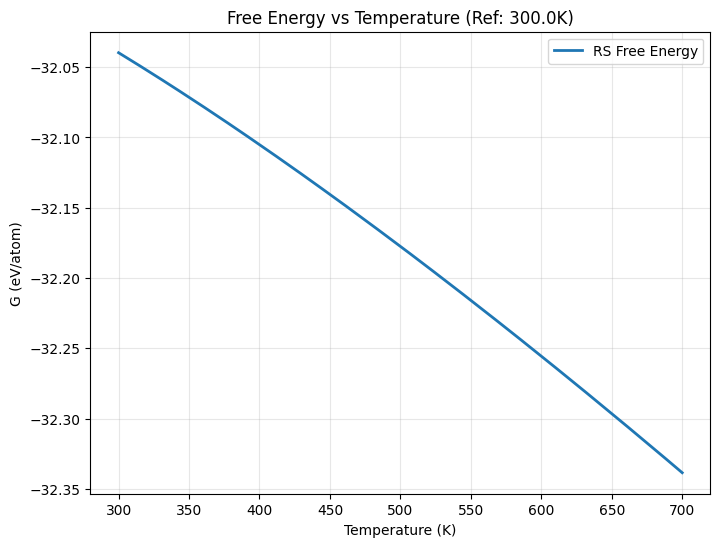

In [1]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
from pandas import read_csv, DataFrame
import sys

# Robust import for cumtrapz (handles SciPy v1.14+ deprecation)
try:
    from scipy.integrate import cumulative_trapezoid as cumtrapz
except ImportError:
    from scipy.integrate import cumtrapz

from ase.units import kB

def analyze_and_save_rs(spring_yaml="ti_spring.yaml", rs_csv="ti_rs.csv", output_csv="rs_free_energy_delta.csv"):
    try:
        # 1. Load Reference State (G0, T0)
        # --------------------------------
        with open(spring_yaml, "r") as f:
            y = yaml.safe_load(f)

        # Handle keys that might vary slightly by GPUMD version
        T0 = y.get("T") or y.get("Temperature")
        G0 = y.get("G") or y.get("Free Energy (eV/atom)")

        if T0 is None or G0 is None:
            print(f"Error: Could not find 'T' or 'G' in {spring_yaml}")
            return

        print(f"Reference State: T0 = {T0} K, G0 = {G0} eV/atom")

        # 2. Load and Process RS Trajectory
        # ---------------------------------
        print(f"Reading {rs_csv}...")
        rs = read_csv(rs_csv)
        
        # Split data into forward and backward paths
        n = int(len(rs)/2)
        forward = rs.iloc[:n].copy()
        backward = rs.iloc[n:].iloc[::-1].copy() # Reverse backward path
        backward.reset_index(inplace=True, drop=True)

        # Determine enthalpy column name
        if "enthalpy" in rs.columns:
            h_col = "enthalpy"
        elif "Potential Energy" in rs.columns:
            h_col = "Potential Energy"
        else:
            print(f"Error: Could not find enthalpy column. Columns: {rs.columns}")
            return

        dl = forward["dlambda"].values
        l = forward["lambda"].values
        H1 = forward[h_col].values
        H2 = backward[h_col].values
        
        # Calculate Temperature array based on lambda scaling
        T = T0 / l

        # 3. Calculate Free Energy (Your Logic)
        # -------------------------------------
        # Calculate work (w) using cumulative trapezoidal rule
        # initial=0 ensures result array is same length as input
        w1 = cumtrapz(H1, l, initial=0)
        w2 = cumtrapz(H2, l, initial=0)
        w = (w1 + w2) * 0.5

        # Apply Reversible Scaling Free Energy Formula
        G = (G0 + 1.5 * kB * T0 * np.log(l) + w) / l

        # 4. Save Final Values to CSV
        # ---------------------------
        # Creating a DataFrame to save T, G, and other useful data
        df_results = DataFrame({
            "Temperature_K": T,
            "Free_Energy_eV_atom": G,
            "Lambda": l,
            "Work_w": w
        })

        df_results.to_csv(output_csv, index=False)
        print(f"✅ Success! Final G and T values saved to: {output_csv}")

        # 5. Plotting (Optional visualization)
        # ------------------------------------
        plt.figure(figsize=(8, 6))
        plt.plot(T, G, label="RS Free Energy", linewidth=2)
        plt.xlabel("Temperature (K)")
        plt.ylabel("G (eV/atom)")
        plt.title(f"Free Energy vs Temperature (Ref: {T0}K)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plot_filename = "G_vs_T_plot.png"
        plt.savefig(plot_filename)
        print(f"Plot saved to: {plot_filename}")

    except FileNotFoundError as e:
        print(f"File Error: {e}")
    except Exception as e:
        print(f"An error occurred: {e}")

if __name__ == "__main__":
    analyze_and_save_rs()